In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("../Data/AirfoilSelfNoise.csv") # load data 

In [3]:
df

,f,alpha,c,U_infinity,delta,SSPL
0,800,0.0,0.3048,71.3,0.002663,126.201
1,1000,0.0,0.3048,71.3,0.002663,125.201
2,1250,0.0,0.3048,71.3,0.002663,125.951
3,1600,0.0,0.3048,71.3,0.002663,127.591
4,2000,0.0,0.3048,71.3,0.002663,127.461
...,...,...,...,...,...,...
1498,2500,15.6,0.1016,39.6,0.052849,110.264
1499,3150,15.6,0.1016,39.6,0.052849,109.254
1500,4000,15.6,0.1016,39.6,0.052849,106.604
1501,5000,15.6,0.1016,39.6,0.052849,106.224


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   f           1503 non-null   int64  
 1   alpha       1503 non-null   float64
 2   c           1503 non-null   float64
 3   U_infinity  1503 non-null   float64
 4   delta       1503 non-null   float64
 5   SSPL        1503 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 70.6 KB


In [ ]:
df.isna().sum() # check for NaNs

f             0
alpha         0
c             0
U_infinity    0
delta         0
SSPL          0
dtype: int64

In [ ]:
df.duplicated().sum()# scanf or duplicates 

np.int64(0)

In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
f,1503.0,2886.380572,3152.573137,200.000000,800.000000,1600.000000,4000.000000,20000.000000
alpha,1503.0,6.782302,5.918128,0.000000,2.000000,5.400000,9.900000,22.200000
c,1503.0,0.136548,0.093541,0.025400,0.050800,0.101600,0.228600,0.304800
U_infinity,1503.0,50.860745,15.572784,31.700000,39.600000,39.600000,71.300000,71.300000
delta,1503.0,0.011140,0.013150,0.000401,0.002535,0.004957,0.015576,0.058411
SSPL,1503.0,124.835943,6.898657,103.380000,120.191000,125.721000,129.995500,140.987000


In [17]:
df.nunique().sort_values()

U_infinity       4
c                6
f               21
alpha           27
delta          105
SSPL          1456
dtype: int64

In [ ]:
df.skew(numeric_only=True).sort_values()# check overall skewness for each feature

SSPL         -0.418952
U_infinity    0.235852
c             0.457457
alpha         0.689164
delta         1.702165
f             2.137084
dtype: float64

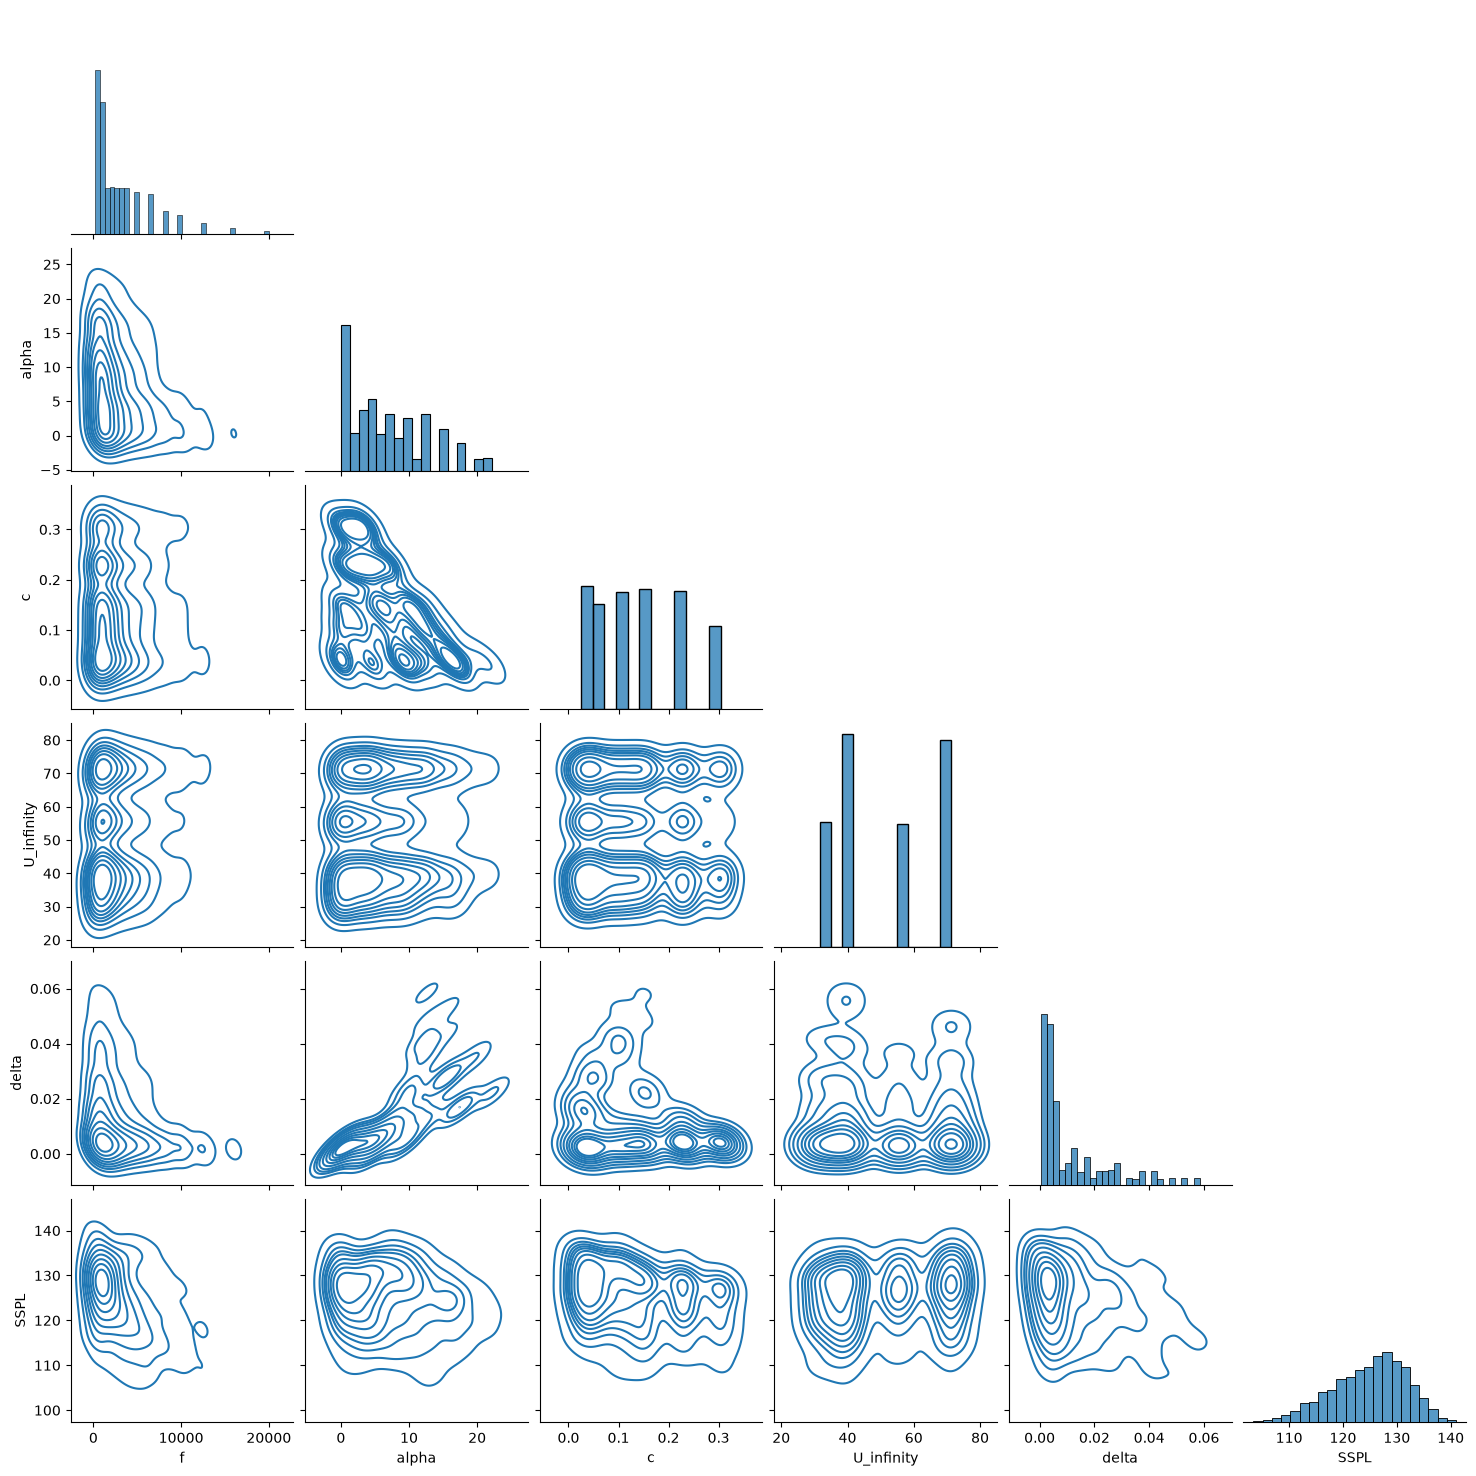

In [4]:
sns.pairplot(df,kind="kde",diag_kind="hist",corner=True)

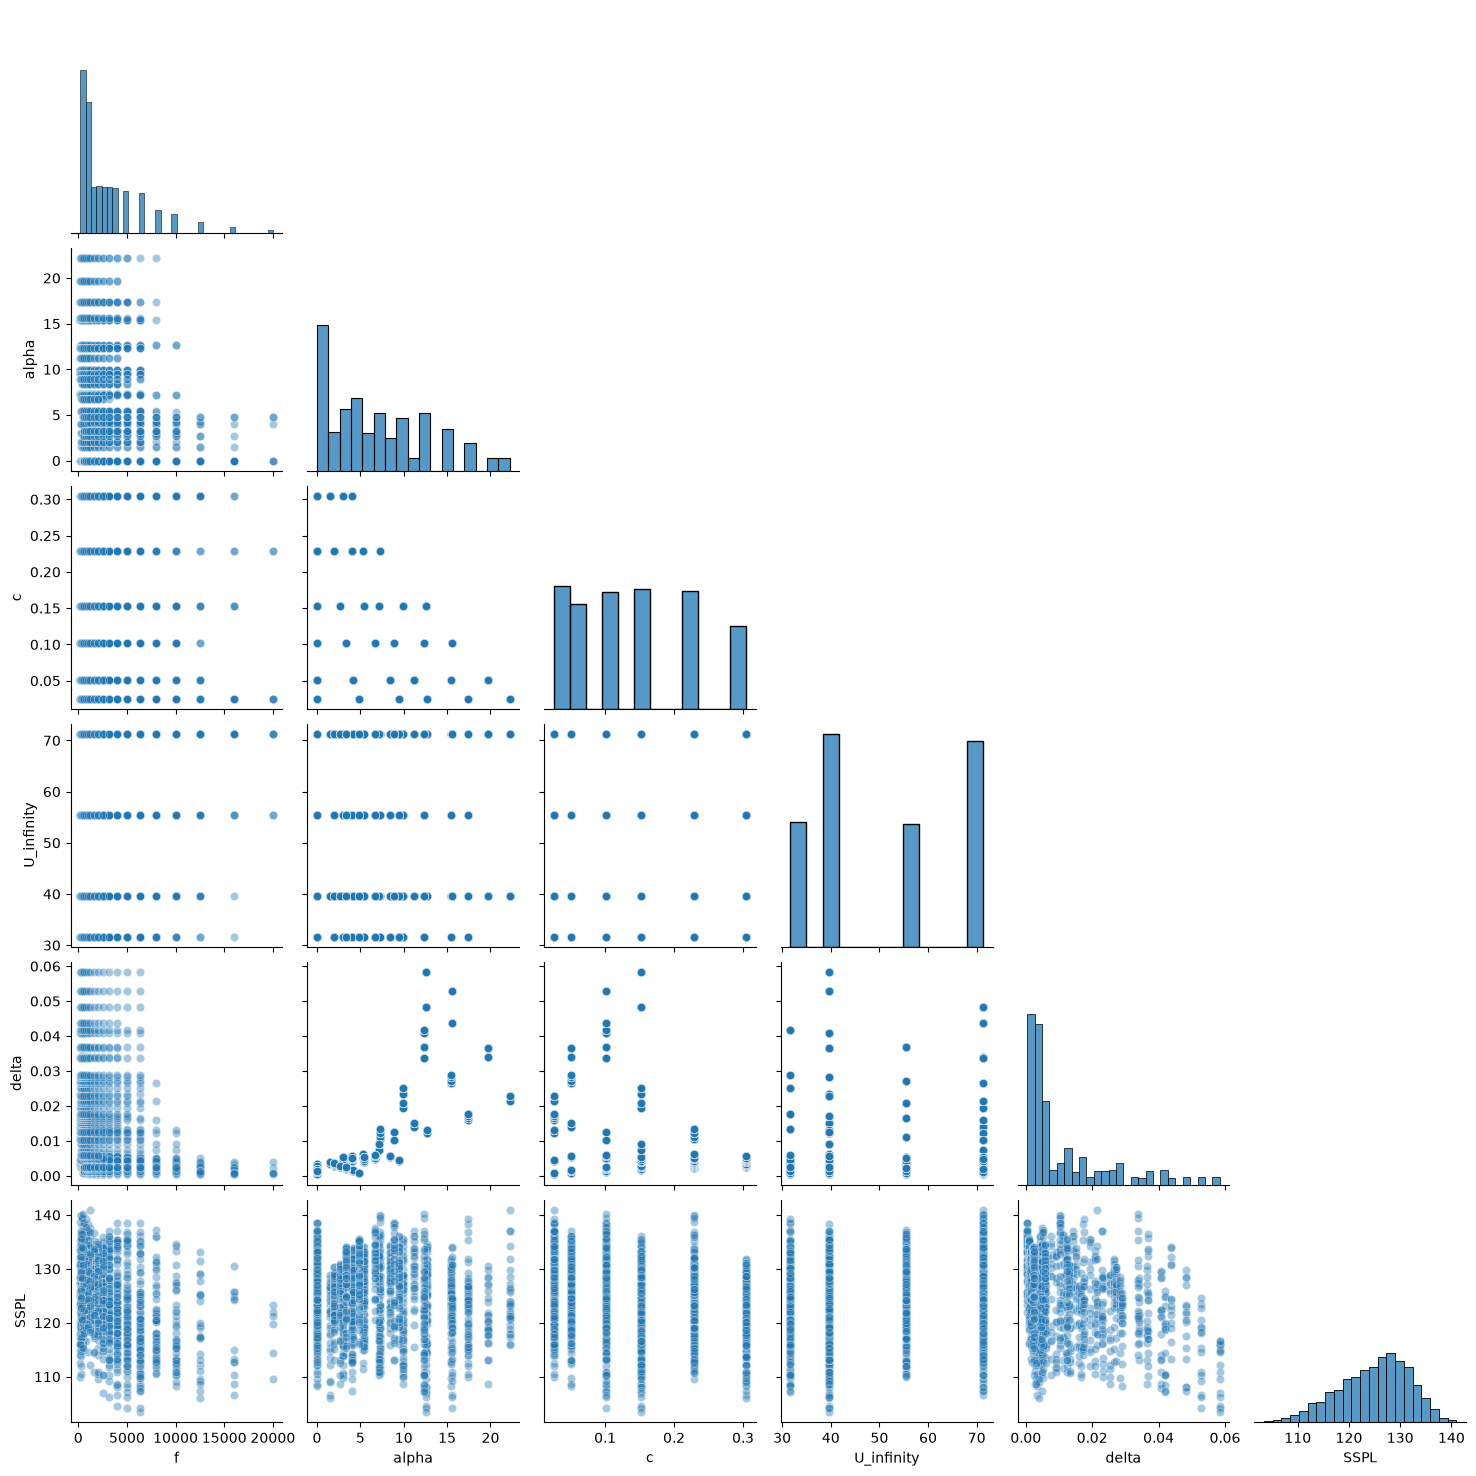

In [5]:
sns.pairplot(df,kind="scatter",diag_kind="hist",corner=True,plot_kws={"alpha":0.4})

In [6]:
df.corr(numeric_only=True)["SSPL"].sort_values()

f            -0.390711
delta        -0.312670
c            -0.236162
alpha        -0.156108
U_infinity    0.125103
SSPL          1.000000
Name: SSPL, dtype: float64

In [11]:
cmap = sns.diverging_palette(5, 250, as_cmap=True)

corr_df = (
    df.corr(numeric_only=True)["SSPL"]
      .sort_values()
      .to_frame()
)

def magnify():
    return [dict(selector="th",
                 props=[("font-size", "16pt")]),
            dict(selector="td",
                 props=[('padding', "0em 0em")]),
            dict(selector="th:hover",
                 props=[("font-size", "16pt")]),
            dict(selector="tr:hover td:hover",
                 props=[('max-width', '200px'),
                        ('font-size', '16pt')])
]



corr_df.style.background_gradient(
    cmap=cmap,
    axis=0
).format(
    precision=3
).set_properties(
    **{"max-width": "120px", "font-size": "16pt"}
).set_caption(
    "Pearsons R correlations"
).set_table_styles(
    magnify()
)

,SSPL
f,-0.391
delta,-0.313
c,-0.236
alpha,-0.156
U_infinity,0.125
SSPL,1.000


In [19]:
pearson = df.corr(numeric_only=True)["SSPL"].sort_values()

spearman = (
    df.corr(method="spearman", numeric_only=True)["SSPL"]
      .sort_values()
)

print("Pearson:")
display(pearson)

print("Spearman:")
display(spearman)

Pearson:


f            -0.390711
delta        -0.312670
c            -0.236162
alpha        -0.156108
U_infinity    0.125103
SSPL          1.000000
Name: SSPL, dtype: float64

Spearman:


f            -0.340783
delta        -0.279844
c            -0.243029
alpha        -0.140768
U_infinity    0.116218
SSPL          1.000000
Name: SSPL, dtype: float64

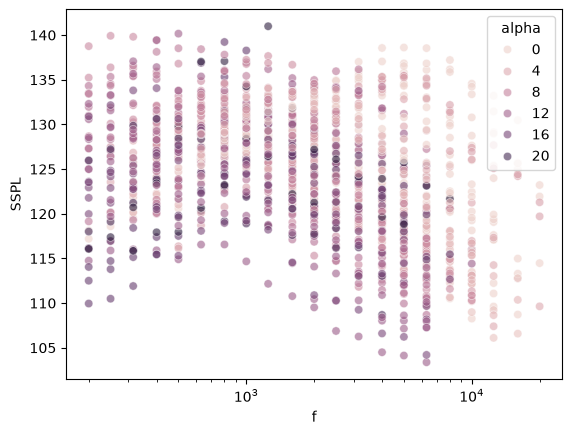

In [22]:
sns.scatterplot(
    data=df,
    x="f",
    y="SSPL",
    hue="alpha",
    alpha=0.6
)

plt.xscale("log")

<Axes: xlabel='alpha', ylabel='SSPL'>

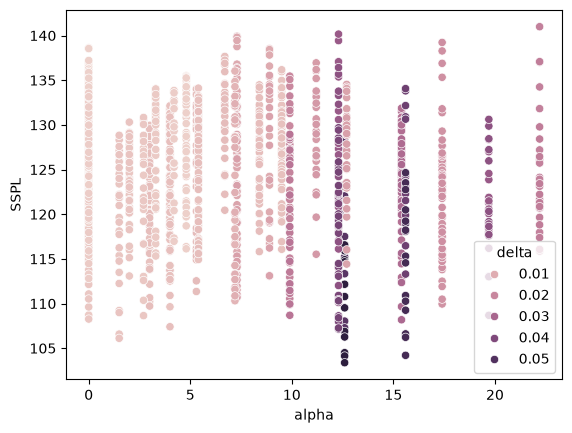

In [23]:
# alpha × displacement thickness
sns.scatterplot(
    data=df,
    x="alpha",
    y="SSPL",
    hue="delta"
)

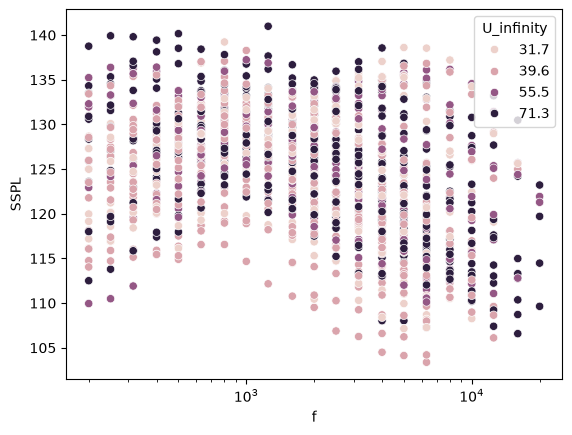

In [24]:
# frequency × velocity
sns.scatterplot(
    data=df,
    x="f",
    y="SSPL",
    hue="U_infinity"
)
plt.xscale("log")

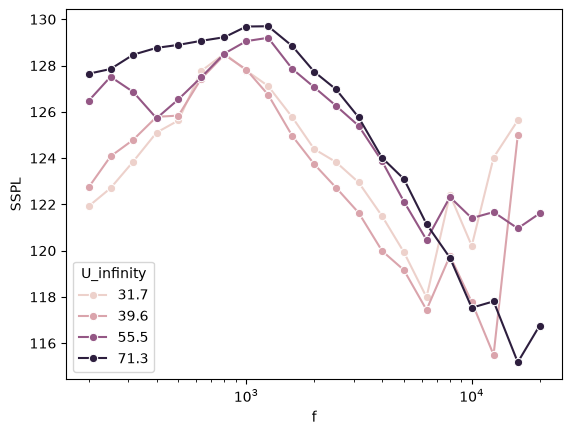

In [25]:
interaction = (
    df.groupby(["f", "U_infinity"])["SSPL"]
      .mean()
      .reset_index()
)

sns.lineplot(
    data=interaction,
    x="f",
    y="SSPL",
    hue="U_infinity",
    marker="o"
)

plt.xscale("log")

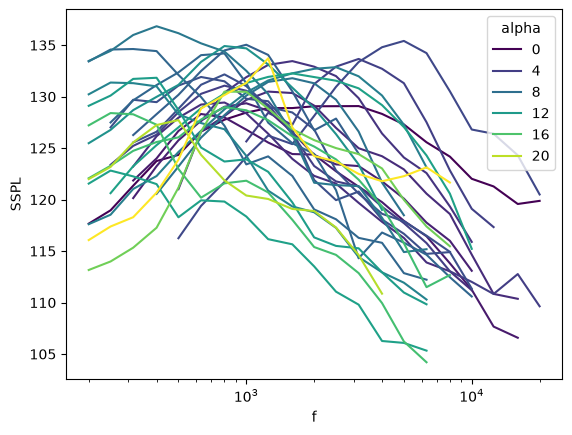

In [26]:
interaction = (
    df.groupby(["f", "alpha"])["SSPL"]
      .mean()
      .reset_index()
)

sns.lineplot(
    data=interaction,
    x="f",
    y="SSPL",
    hue="alpha",
    palette="viridis"
)

plt.xscale("log")